# Builder Tutorial

In this tutorial, we demonstrate the high-level interface of `ls_bayesian`'s SPDE prior subpackage
through its `builder` module. The tutorial focuses on brevity, and
showcases the prior setup on a non-standard mesh. For a more thorough introduction to the internals
and mathematical background of the SPDE prior, we refer to the [components](./components.ipynb)
tutorial.

## Imports and Configuration

We import `DOLFINx` for mesh handling, `PyVista` for visualization, and the
`builder` and `fem` modules from
`ls_bayesian`.

In [1]:
import dolfinx as dlx
import numpy as np
import pyvista as pv
from mpi4py import MPI

from ls_bayesian.spde_prior import builder, fem, strategies

pv.global_theme.jupyter_backend = "static"

## Read in Mesh

We showcase the construction of a prior distribution on a 2D embedded surface, namely the
left-atrial manifold (the upper left chamber of the human heart). The mesh we use is stored in
[msh](https://gmsh.info/) format, which can easily be converted to an MPI-parallel `DOLFINx` mesh.

In [2]:
mesh, *_ = dlx.io.gmsh.read_from_msh("left_atrium_surface.msh", MPI.COMM_WORLD, rank=0, gdim=3)

Info    : Reading 'left_atrium_surface.msh'...
Info    : 1 entity
Info    : 8843 nodes
Info    : 17444 elements
Info    : Done reading 'left_atrium_surface.msh'


## Configure Prior

Given our `DOLFINx` mesh, we construct an `SPDEPrior`
object with the builder component. As of now, the builder supports Bilaplace priors, selected via
a [`BilaplacianComponentStrategy`][ls_bayesian.spde_prior.strategies.BilaplacianComponentStrategy]
(see the [components](./components.ipynb) tutorial for an explanation of the underlying
mathematics). To configure the builder, we set up a
`SPDEPriorSettings` data class. As
mandatory settings, the configuration class requires the mesh, a mean vector defined on the mesh's
vertices, and the parameters $\tau$ and $\kappa$ of the prior. The prior can be configured further,
see the [class documentation][ls_bayesian.spde_prior.builder.SPDEPriorSettings] and the
[components](./components.ipynb) tutorial for more details.

In [3]:
prior_settings = builder.SPDEPriorSettings(
    mesh=mesh,
    mean_vector=np.zeros(mesh.geometry.x.shape[0]),
    kappa=0.5,
    tau=1,
)

## Set Up with Builder

With our configuration and a component strategy, we can set up an
`SPDEPriorBuilder` and invoke its
`build` method to generate an
`SPDEPrior` object. The strategy determines which composition of FEM matrices realizes the
prior's operators; here we select the bilaplacian composition via
`BilaplacianComponentStrategy`.

In [4]:
prior_builder = builder.SPDEPriorBuilder(
    prior_settings, strategies.BilaplacianComponentStrategy()
)
bilaplace_prior = prior_builder.build()

## Test Functionality

Like in the [components](./components.ipynb) tutorial, we showcase the functionality of the prior:
evaluating the cost, gradient, and Hessian-vector product at test vectors, and generating a sample
from the prior distribution.

In [5]:
num_vertices = mesh.geometry.x.shape[0]
test_vector_1 = np.ones(num_vertices)
test_vector_2 = 2 * np.ones(num_vertices)
test_vector_3 = 3 * np.ones(num_vertices)

cost = bilaplace_prior.evaluate_cost(test_vector_1)
grad = bilaplace_prior.evaluate_gradient(test_vector_2)
hvp = bilaplace_prior.evaluate_hessian_vector_product(test_vector_3)
sample = bilaplace_prior.generate_sample()

## Visualize Sample

We can further visualize the sample over the atrial manifold.

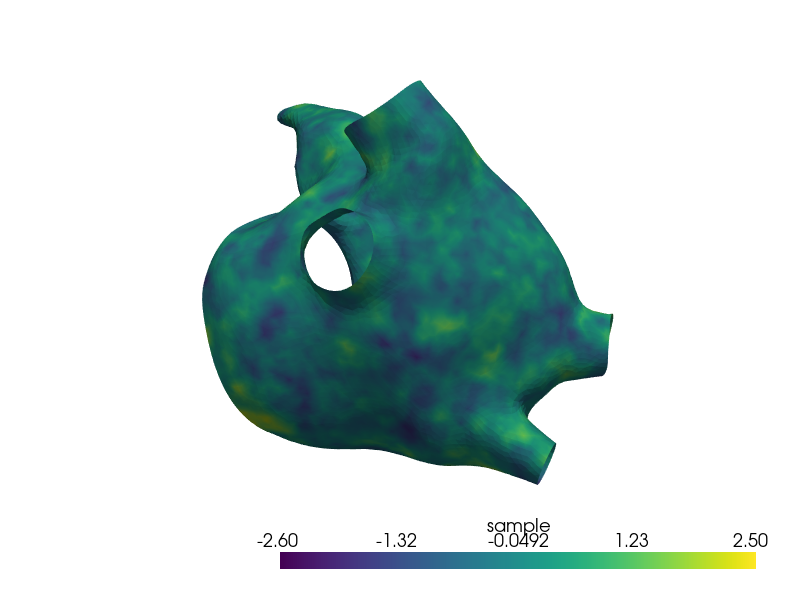

In [6]:
# Vertex vectors from spde_prior (e.g. `sample` below) are ordered by input node index, not
# by dolfinx's own internal geometry order, so the plotting geometry must match that order.
vertices, simplices = fem.get_ordered_vertices_and_cells(mesh)

camera_position = [
    (92.7033800655023, -107.54971248826202, -146.9233989237418),
    (5.789453506469723, -8.405534744262697, 10.9196138381958),
    (0.64544246900107, 0.7545534378669008, -0.11854589243429736),
]
pv_mesh = pv.PolyData.from_regular_faces(vertices, simplices)
pv_mesh.point_data["sample"] = sample
plotter = pv.Plotter()
plotter.add_mesh(pv_mesh, scalars="sample", cmap="viridis", show_edges=False, show_scalar_bar=True)
plotter.show(window_size=[800, 600], cpos=camera_position)
plotter.close()